In [1]:
import mi_quantum as qtm
import torch

In [2]:
p = {
    'lr': 0.0035,  # Recommended:  0.0025 for classical data and 0.00025 for quantum data
    'patch_size': 4,
    'dropout': {'embedding_attn': 0.175, 'after_attn': 0.175, 'feedforward': 0.1, 'embedding_pos': 0.1},
    'num_head': 4,
    'num_transf': 2,
    'RBF_similarity': 'none',  # ['quantum', 'linear'],
    'mlp_size': [3, 4, 5],
    'weight_decay': 1e-7,
    'attention_selection': 'filter',  # Options: 'none', 'filter', 'ID', 'MLP'
    'entangle': True,
    'RD': 1,  # Reduction factor for attention selection
    'paralel': 1,
    'patience': -1,  # No early stopping
    'connectivity': 'star',  # Options: 'chain (range = 1)', 'david_star', 'star (range = 1 + range = 2)' (david star only available for 6 qubits)
    'scheduler_factor': 0.998,
    'q_stride': 1,  # Quantum stride
    'quantum_data': 'none',  # If True, uses quantum data
    'quantum_mlp': True,  # If True, uses quantum MLP inter transformer
    'quantum_classification': False,
    'train_q': True
}

model3 = qtm.quantum.VisionTransformer(
            data_type="original", img_size=28, num_channels=3, num_classes=7,
            patch_size=p['patch_size'], hidden_size= 3 * p['patch_size']**2, num_heads=p['num_head'],
            num_transformer_blocks=p['num_transf'], attention_selection=p['attention_selection'], RBF_similarity = p['RBF_similarity'],
            mlp_hidden_size=p['mlp_size'][0], quantum_mlp = p['quantum_mlp'], train_q = p['train_q'], dropout=p['dropout'], channels_last=False, entangle=p['entangle'], 
            quantum_classification = p['quantum_classification'], RD= p['RD'], paralel=p['paralel'], connectivity='david_star'
        )


TypeError: VisionTransformer.__init__() got an unexpected keyword argument 'data_type'

In [ ]:
model4 = qtm.quantum.VisionTransformer(
            data_type="original", img_size=28, num_channels=3, num_classes=7,
            patch_size=p['patch_size'], hidden_size= 3 * p['patch_size']**2, num_heads=p['num_head'],
            num_transformer_blocks=p['num_transf'], attention_selection=p['attention_selection'], RBF_similarity = p['RBF_similarity'],
            mlp_hidden_size=p['mlp_size'][1], quantum_mlp = p['quantum_mlp'], train_q = p['train_q'], dropout=p['dropout'], channels_last=False, entangle=p['entangle'], 
            quantum_classification = p['quantum_classification'], RD= p['RD'], paralel=p['paralel'], connectivity='david_star'
        )

model4.load_state_dict(torch.load('derma_results/current_results/grid_search0model_weights_val_0.0035_48_custom_4_2_4_4_1e-07.pth.csv'))

model5 = qtm.quantum.VisionTransformer(
            data_type="original", img_size=28, num_channels=3, num_classes=7,
            patch_size=p['patch_size'], hidden_size= 3 * p['patch_size']**2, num_heads=p['num_head'],
            num_transformer_blocks=p['num_transf'], attention_selection=p['attention_selection'], RBF_similarity = p['RBF_similarity'],
            mlp_hidden_size=p['mlp_size'][2], quantum_mlp = p['quantum_mlp'], train_q = p['train_q'], dropout=p['dropout'], channels_last=False, entangle=p['entangle'], 
            quantum_classification = p['quantum_classification'], RD= p['RD'], paralel=p['paralel'], connectivity='david_star'
        )

model5.load_state_dict(torch.load('derma_results/current_results/grid_search0/model_weights_val_0.0035_48_custom_4_2_5_4_1e-07.pth.csv'))

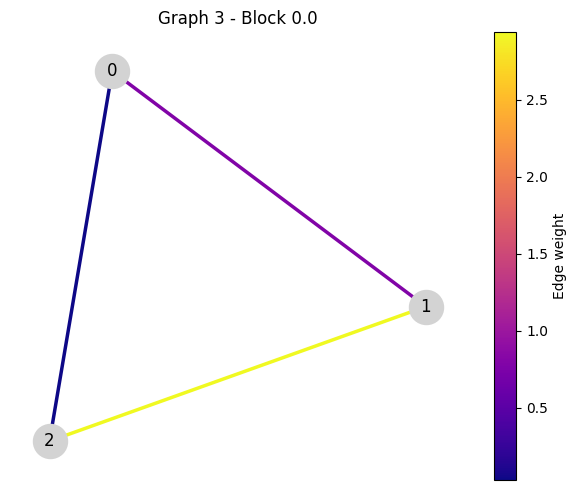

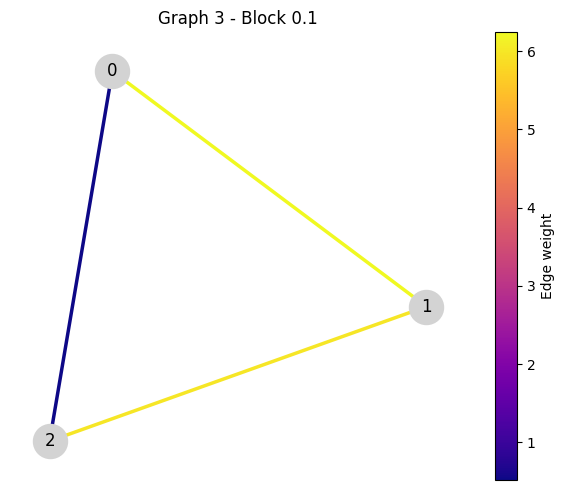

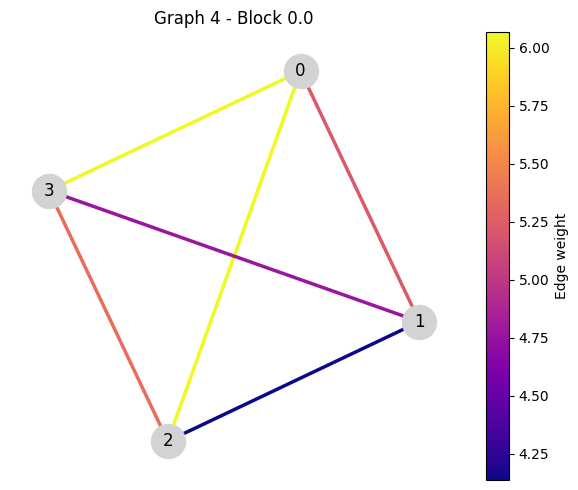

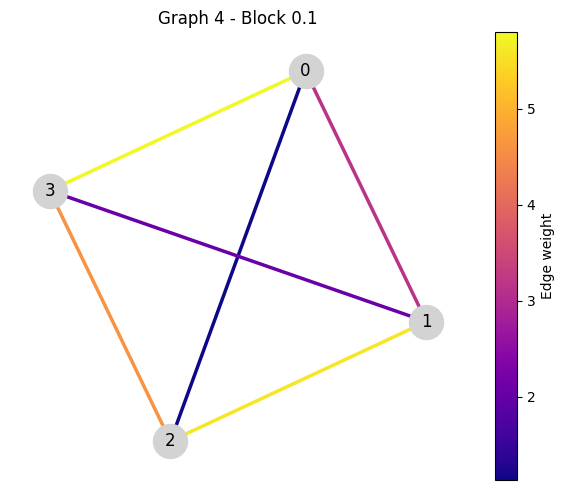

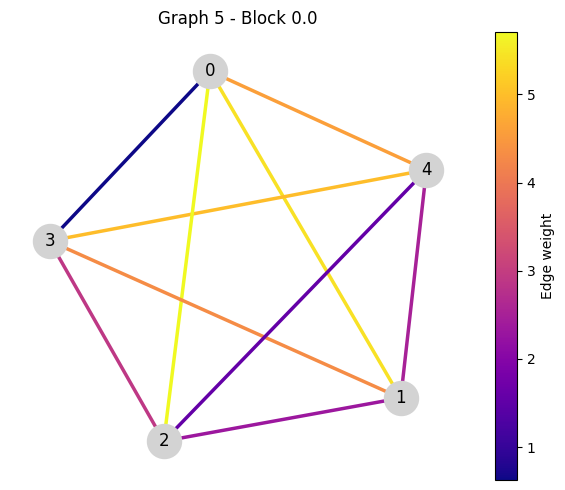

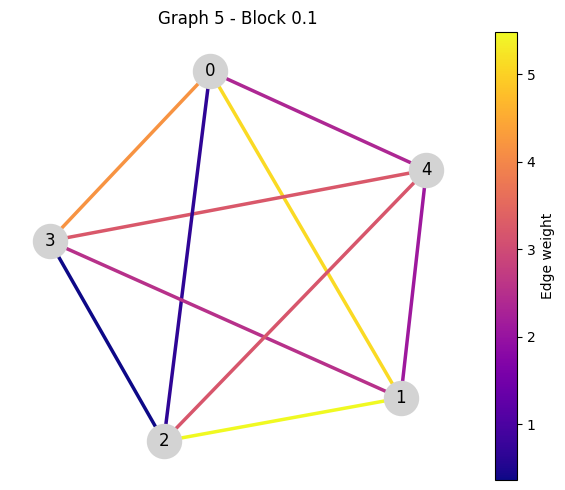

In [ ]:
import torch
import networkx as nx
import matplotlib.pyplot as plt

# Your graph definitions
graphs = {
    3: [[0, 1], [1, 2], [2, 0]],
    4: [[0, 1], [1, 2], [2, 3], [3, 0], [0, 2], [1, 3]],
    5: [[0, 1], [1, 2], [2, 3], [3, 4], [4, 0], [0, 2], [1, 3], [2, 4], [3, 0], [4, 1]]
}

# Load weights
weights3 =  torch.load('derma_results/current_results/grid_search1/model_weights_val_0.0035_48_custom_4_2_3_4_1e-07.pth', weights_only= True)
weights4 =  torch.load('derma_results/current_results/grid_search1/model_weights_val_0.0035_48_custom_4_2_4_4_1e-07.pth', weights_only= True)
weights5 =  torch.load('derma_results/current_results/grid_search1/model_weights_val_0.0035_48_custom_4_2_5_4_1e-07.pth', weights_only= True)

# Helper function to plot each graph
def plot_graph_with_weights(graph_edges, weights, title):
    G = nx.Graph()
    G.add_edges_from(graph_edges)

    # Get weights for the edges (last len(edges) values)
    edge_weights = weights[-len(graph_edges):].cpu().numpy()

    pos = nx.spring_layout(G, seed=42)  # consistent layout

    plt.figure(figsize=(6, 5))
    ax = plt.gca()  # Get current Axes

    # Draw the graph and capture the returned LineCollection for colorbar
    edges = nx.draw_networkx_edges(
        G, pos, edgelist=graph_edges,
        edge_color=edge_weights, edge_cmap=plt.cm.plasma, edge_vmin=min(edge_weights),
        edge_vmax=max(edge_weights), width=2.5, ax=ax
    )
    nx.draw_networkx_nodes(G, pos, node_color='lightgray', node_size=600, ax=ax)
    nx.draw_networkx_labels(G, pos, ax=ax)

    # Add colorbar
    sm = plt.cm.ScalarMappable(cmap=plt.cm.plasma, norm=plt.Normalize(vmin=min(edge_weights), vmax=max(edge_weights)))
    sm.set_array(edge_weights)
    plt.colorbar(sm, ax=ax, label="Edge weight")

    plt.title(title)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


# Plotting
plot_graph_with_weights(graphs[3],
                        weights3['transformer_blocks.0.0.mlp_sel.vqc.magic.weights'],
                        "Graph 3 - Block 0.0")

plot_graph_with_weights(graphs[3],
                        weights3['transformer_blocks.0.1.mlp_sel.vqc.magic.weights'],
                        "Graph 3 - Block 0.1")

plot_graph_with_weights(graphs[4],
                        weights4['transformer_blocks.0.0.mlp_sel.vqc.magic.weights'],
                        "Graph 4 - Block 0.0")

plot_graph_with_weights(graphs[4],
                        weights4['transformer_blocks.0.1.mlp_sel.vqc.magic.weights'],
                        "Graph 4 - Block 0.1")

plot_graph_with_weights(graphs[5],
                        weights5['transformer_blocks.0.0.mlp_sel.vqc.magic.weights'],
                        "Graph 5 - Block 0.0")

plot_graph_with_weights(graphs[5],
                        weights5['transformer_blocks.0.1.mlp_sel.vqc.magic.weights'],
                        "Graph 5 - Block 0.1")


In [ ]:
import torch

def multilinear_form(A: torch.Tensor, vectors: list[torch.Tensor]) -> torch.Tensor:
    """
    Computes the multilinear form for an n-tensor A and n vectors:
    sum over all indices of A[i1, i2, ..., in] * v1[i1] * v2[i2] * ... * vn[in]

    Parameters:
    - A: torch.Tensor of shape (d, d, ..., d) with n dimensions
    - vectors: list of n torch.Tensors, each of shape (d,)

    Returns:
    - scalar (0D torch.Tensor)
    """
    n = A.dim()
    assert len(vectors) == n, f"Expected {n} vectors, got {len(vectors)}"

    # Create the Einstein summation string: e.g. for n=3 -> 'ijk,i,j,k->'
    # We'll assign letters from the alphabet for each dimension
    letters = 'abcdefghijklmnopqrstuvwxyz'
    assert n <= len(letters), "Too many dimensions for einsum letters."

    # Construct einsum subscripts
    A_subscript = letters[:n]
    vectors_subscripts = ','.join(letters[i] for i in range(n))
    einsum_str = f'{A_subscript},{vectors_subscripts}->'

    return torch.einsum(einsum_str, A, *vectors)

def identity_tensor(d: int, n: int) -> torch.Tensor:
    """
    Creates an n-dimensional identity tensor of shape (d, d, ..., d)
    with ones where all indices are equal, zeros elsewhere.
    """
    # Create an n-dimensional grid of indices
    indices = torch.arange(d)
    # Generate n copies of indices for broadcasting
    grids = torch.meshgrid(*([indices] * n), indexing='ij')
    # Stack to get shape (n, d, d, ..., d)
    stacked = torch.stack(grids)  # shape: (n, d, d, ..., d)

    # Check where all indices along the first dimension are equal
    # That is, all equal along axis=0
    equal_mask = torch.all(stacked == stacked[0], dim=0)

    return equal_mask.to(dtype=torch.float32)


Tensor_Dimension = 3
Embedding_Dimension = 3

A = identity_tensor(Embedding_Dimension, Tensor_Dimension) # torch.randn(*([d] * n))
print("Identity tensor A shape:", A.shape, "\n", A)
vectors = [torch.ones(Embedding_Dimension)*(_+1) for _ in range(Tensor_Dimension)]

result = multilinear_form(A, vectors)
print("Multilinear form result:", result.item())

Identity tensor A shape: torch.Size([3, 3, 3]) 
 tensor([[[1., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 1., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 1.]]])
Multilinear form result: 18.0


In [ ]:
import torch
import torch.nn as nn
import numbers

class NMultiheadSelfAttention(nn.Module):
    def __init__(
        self,
        embed_dim,
        num_heads,
        N=2,  # Order of multilinear form
        dropout={'embedding_attn': 0.225, 'after_attn': 0.225, 'feedforward': 0.225, 'embedding_pos': 0.225},
        RBF_similarity='none',
    ):
        super().__init__()
        assert embed_dim % num_heads == 0, f"Embedding dim {embed_dim} must be divisible by num_heads {num_heads}"

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.N = N
        self.RBF_similarity = RBF_similarity

        if self.N < 2:
            raise ValueError("N (order of multilinear form) must be at least 2.")
        elif self.N > 2 and self.RBF_similarity != 'none':
            raise ValueError("RBF similarity only implemented for N=2.")

        assert (
            RBF_similarity in ['none', 'quantum', 'linear']
            or (isinstance(RBF_similarity, numbers.Real) and 0 < RBF_similarity <= 1)  # type: ignore
        ), f"Invalid RBF_similarity: {RBF_similarity}"


        if self.RBF_similarity == 'quantum':
            self.quantum_ponderation = QuantumLayer(num_qubits=2, entangle=True, trainBool=True, graph='chain')
        elif self.RBF_similarity == 'linear':
            self.ponderation_param = nn.Parameter(torch.tensor(0.0))

        # One projection per tensor dimension
        self.projections = nn.ModuleList([nn.Linear(embed_dim, embed_dim) for _ in range(N)])

        self.v_proj = nn.Linear(embed_dim, embed_dim)  # Dedicated value projection
        self.o_proj = nn.Linear(embed_dim, embed_dim)
        self.dropout = nn.Dropout(dropout['embedding_attn'])

        # Learnable N-way tensor for multilinear attention
        if N != 2:
            self.A = nn.Parameter(torch.randn(*(self.N * (self.head_dim,))))
        else:
            self.register_buffer('A_identity', identity_tensor(d=self.head_dim, n=2))
    

    def forward(self, x):
        B, S, E = x.shape
        assert E == self.embed_dim

        # compute the N projections: each proj -> (B, S, H, D) then transpose to (B, H, S, D)
        proj_x = [
            proj(x).view(B, S, self.num_heads, self.head_dim).transpose(1, 2)  # -> (B, H, S, D)
            for proj in self.projections
        ]

        # build einsum string:
        # A has indexes a0 a1 ... a_{N-1}
        # projection n has subscript "b h token_n letter_n" where token_n is:
        #   - 'i' for mode 0 (query axis, kept)
        #   - 'j' for mode 1 (key axis, kept)
        #   - 's' for modes 2..N-1 (context axes, summed/marginalized)
        #
        # Result should be 'b h i j'
        # pools of letters
        tokens = list("ijk")  # token positions
        embeds = list("acdefguvwxyzlmnopqrst")  # embedding dims (avoid b,h,i,j,k,... collisions)

        assert self.N <= len(embeds), f"N too large, max {len(embeds)}"
        
        # subscripts for A (the N-way tensor)
        A_sub = "".join(embeds[:self.N])  # e.g. "abc" for N=3
        
        proj_subs = []
        for n in range(self.N):
            token = tokens[n] if n < 2 else tokens[2]  # first two → i,j ; rest → s (context)
            dim = embeds[n]                            # unique embedding letter
            proj_subs.append(f"bh{token}{dim}")
        
        # result: always bhij (standard 2D attention map)
        einsum_str = f"{A_sub}," + ",".join(proj_subs) + "->bhij"

        # Example N=3: 'acd,bhia,bhjc,bhkd->bhij'

        # execute einsum, resulting shape -> (B, H, S, S)
        # (this implicitly sums over the 's' token index for context modes)
        A = self.A if self.N != 2 else self.A_identity.to(x.device)
        attn_logits = torch.einsum(einsum_str, A, *proj_x)  # (B, H, S, S)

        # scale (similar to standard attention)
        attn_logits = attn_logits / (self.head_dim ** 0.5)

        # softmax over keys (j) to get attention weights per query i
        attn = torch.softmax(attn_logits, dim=-1)
        attn = self.dropout(attn)

        if self.RBF_similarity != 'none':
                if self.N != 2:
                    raise ValueError("RBF similarity is only implemented for standard 2D tensors products (Query and Key) ")
                # Compute RBF similarity
                if self.RBF_similarity == 'quantum':
                    ponderators = torch.sigmoid( self.quantum_ponderation( torch.zeros( (2,), device = x.device) ))
                elif isinstance(self.RBF_similarity, numbers.Real):    
                    ponderators = torch.tensor([1 - self.RBF_similarity, self.RBF_similarity], device=x.device, dtype=torch.float32)
                else: # RBF_similarity == 'linear'
                    sigmoid_val = torch.sigmoid(self.ponderation_param)
                    ponderators = torch.stack([1 - sigmoid_val, sigmoid_val])

                # promote to float32 for stability
                q32 = proj_x[0].float()
                k32 = proj_x[1].float()

                q_norm = (q32 ** 2).sum(dim=-1, keepdim=True)            # (B,H,S,1)
                k_norm = (k32 ** 2).sum(dim=-1, keepdim=True).transpose(-2, -1)  # (B,H,1,S)

                # distance
                dists_squared = q_norm + k_norm - 2 * (q32 @ k32.transpose(-2, -1))

                # clamp negative numerical noise
                dists_squared = dists_squared.clamp_min(0.0)

                # scale (avoid too-small / too-large)
                sigma_squared = q_norm.clamp_min(1e-8).clamp_max(1e4)  # tune upper bound as needed

                attn_RBF_logits = torch.exp(-dists_squared / sigma_squared)

                denom = attn_RBF_logits.sum(dim=-1, keepdim=True).clamp_min(1e-8)
                attn_RBF = attn_RBF_logits / denom

                attn_RBF = self.dropout(attn_RBF)

                if (~torch.isfinite(attn_RBF)).any():
                    import warnings
                    print(f"Registered non-finite attn. ponderators={ponderators}")
                    warnings.warn(f"Non-finite RBF attention detected. Ponderators = {ponderators}", RuntimeWarning)
                    
                # sanitize just in case
                attn_RBF = torch.nan_to_num(attn_RBF, nan=0.0, posinf=0.0, neginf=0.0)

                # mix (ponderators assumed roughly sum=1 but be safe)

                weight_sum = ponderators[0] + ponderators[1]
                attn = (ponderators[0] * attn + ponderators[1] * attn_RBF) / (weight_sum + 1e-7)

        # compute values using dedicated v_proj (so values are independent of mode projections)
        v = self.v_proj(x).view(B, S, self.num_heads, self.head_dim).transpose(1, 2)  # (B,H,S,D)

        # weighted sum: (B,H,S,D) = sum_j attn[b,h,i,j] * v[b,h,j,d]
        values = torch.einsum("bhij,bhjd->bhid", attn, v)

        # reshape back to (B, S, E)
        values = values.transpose(1, 2).reshape(B, S, E)

        out = self.o_proj(values)

        return out, attn

class MultiheadSelfAttention(nn.Module):
        def __init__(self, embed_dim, num_heads, dropout={'embedding_attn': 0.225, 'after_attn': 0.225, 'feedforward': 0.225, 'embedding_pos': 0.225}, RBF_similarity = False, tensor_dimension = 2):
            super().__init__()
            assert embed_dim % num_heads == 0, f"Embedding dimension ({embed_dim}) should be divisible by number of heads ({num_heads})"

            self.embed_dim = embed_dim
            self.num_heads = num_heads
            self.head_dim = embed_dim // num_heads
            self.tensor_dimension = tensor_dimension
            assert RBF_similarity == 'none' or RBF_similarity == 'quantum' or RBF_similarity == 'linear' or (isinstance(RBF_similarity, numbers.Real) and 0 < RBF_similarity <= 1), f"RBF_similarity must be set to 'none', 'quantum', 'linear' or a float between 0 and 1, but got {RBF_similarity}"
            self.RBF_similarity = RBF_similarity
            print(f'Setting up multihead self-attention with RBF_similarity: {self.RBF_similarity}')

            if self.RBF_similarity == 'quantum':
                self.quantum_ponderation = QuantumLayer(num_qubits=2, entangle= True, trainBool= True, graph= 'chain' )
            elif self.RBF_similarity == 'linear':
                self.ponderation_param = nn.Parameter(torch.tensor(0.0))  # initialized at 0 → sigmoid = 0.5
    
            print('Started a MutliheadSelfAttention layer with embed_dim:', embed_dim, 'num_heads:', num_heads, 'head_dim:', self.head_dim, 'RBF_similarity:', self.RBF_similarity)

            self.q_proj = nn.Linear(embed_dim, embed_dim)
            self.k_proj = nn.Linear(embed_dim, embed_dim)
            self.v_proj = nn.Linear(embed_dim, embed_dim)
            self.dropout = nn.Dropout(dropout['embedding_attn'])
            self.o_proj = nn.Linear(embed_dim, embed_dim)

        def rank_patches_by_attention(attn: torch.Tensor) -> torch.Tensor:
            """
            Ranks image patches by the total attention they receive.

            """
            # Average over heads: (B, T, T)
            attn_mean = attn.mean(dim=1)

            # Total attention received by each token: sum over the source positions (axis=-2)
            # attention_received[b, j] = sum over i of attn[b, i, j]
            attention_received = attn_mean.sum(dim=1)  # shape: (B, T)

            # Sort patches by total attention received, descending
            sorted_indices = attention_received.argsort(dim=1, descending=True)  # shape: (B, T)

            return sorted_indices



        def forward(self, x):
            batch_size, seq_len, embed_dim = x.shape
            # x.shape = (batch_size, seq_len, embed_dim)
            assert embed_dim == self.embed_dim, f"Input embedding dimension ({embed_dim}) should match layer embedding dimension ({self.embed_dim})"

            q, k, v = [
                proj(x).reshape(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
                for proj, x in zip([self.q_proj, self.k_proj, self.v_proj], [x, x, x])
            ]

            # Compute scaled dot-product attention
            qk_dot = q @ k.transpose(-2, -1)

            attn_logits = ( qk_dot / (self.head_dim ** 0.5))
            # attn_logits.shape = (batch_size, num_heads, seq_len, seq_len)
            attn = attn_logits.softmax(dim=-1)
            # attn.shape = (batch_size, num_heads, seq_len, seq_len)
            attn = self.dropout(attn)

            if self.RBF_similarity != 'none':
                if self.tensor_dimension != 2:
                    raise ValueError("RBF similarity is only implemented for standard 2D tensors products (Query and Key) ")
                # Compute RBF similarity
                if self.RBF_similarity == 'quantum':
                    ponderators = torch.sigmoid( self.quantum_ponderation( torch.zeros( (2,), device = x.device) ))
                elif isinstance(self.RBF_similarity, numbers.Real):    
                    ponderators = torch.tensor([1 - self.RBF_similarity, self.RBF_similarity], device=x.device, dtype=torch.float32)
                else: # RBF_similarity == 'linear'
                    sigmoid_val = torch.sigmoid(self.ponderation_param)
                    ponderators = torch.stack([1 - sigmoid_val, sigmoid_val])

                # promote to float32 for stability
                q32 = q.float()
                k32 = k.float()

                q_norm = (q32 ** 2).sum(dim=-1, keepdim=True)            # (B,H,S,1)
                k_norm = (k32 ** 2).sum(dim=-1, keepdim=True).transpose(-2, -1)  # (B,H,1,S)

                # distance
                dists_squared = q_norm + k_norm - 2 * (q32 @ k32.transpose(-2, -1))

                # clamp negative numerical noise
                dists_squared = dists_squared.clamp_min(0.0)

                # scale (avoid too-small / too-large)
                sigma_squared = q_norm.clamp_min(1e-8).clamp_max(1e4)  # tune upper bound as needed

                attn_RBF_logits = torch.exp(-dists_squared / sigma_squared)

                denom = attn_RBF_logits.sum(dim=-1, keepdim=True).clamp_min(1e-8)
                attn_RBF = attn_RBF_logits / denom

                attn_RBF = self.dropout(attn_RBF)

                if (~torch.isfinite(attn_RBF)).any():
                    import warnings
                    print(f"Registered non-finite attn. ponderators={ponderators}")
                    warnings.warn(f"Non-finite RBF attention detected. Ponderators = {ponderators}", RuntimeWarning)
                    
                # sanitize just in case
                attn_RBF = torch.nan_to_num(attn_RBF, nan=0.0, posinf=0.0, neginf=0.0)

                # mix (ponderators assumed roughly sum=1 but be safe)

                weight_sum = ponderators[0] + ponderators[1]
                attn = (ponderators[0] * attn + ponderators[1] * attn_RBF) / (weight_sum + 1e-7)


            # Compute output
            values = attn @ v
            # values.shape = (batch_size, num_heads, seq_len, head_dim)
            values = values.transpose(1, 2).reshape(batch_size, seq_len, embed_dim)
            # values.shape = (batch_size, seq_len, embed_dim)
            x = self.o_proj(values)
            # x.shape = (batch_size, seq_len, embed_dim)

            return x, attn

NHead2 = NMultiheadSelfAttention(embed_dim=48, num_heads=2, N=2, RBF_similarity='linear')
NHead3 = NMultiheadSelfAttention(embed_dim=48, num_heads=1, N=3, RBF_similarity='none')
NHead4 = NMultiheadSelfAttention(embed_dim=48, num_heads=1, N=4, RBF_similarity='none')

Head2 = MultiheadSelfAttention(embed_dim=48, num_heads=2, RBF_similarity='linear')


x = torch.randn(2, 10, 48)  # (B, S, E)

Setting up multihead self-attention with RBF_similarity: linear
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 2 head_dim: 24 RBF_similarity: linear


In [ ]:
out, attn = NHead3(x)

out, attn = NHead4(x)

Einsum string: acd,bhia,bhjc,bhkd->bhij
Attention logits shape: torch.Size([2, 1, 10, 10])
Einsum string: acde,bhia,bhjc,bhkd,bhke->bhij
Attention logits shape: torch.Size([2, 1, 10, 10])


# Comprobación de que coincida en el caso $N=2$ y $A=I_2$

In [ ]:
NHead2.eval() # Multilinear
Head2.eval()  # Standard
A = identity_tensor(24, 2)

NHead2.A.data = A

NHead2.projections[0].weight.data = Head2.q_proj.weight.data.clone()
NHead2.projections[1].weight.data = Head2.k_proj.weight.data.clone()
NHead2.v_proj.weight.data = Head2.v_proj.weight.data.clone()
NHead2.o_proj.weight.data = Head2.o_proj.weight.data.clone()

NHead2.projections[0].bias.data = Head2.q_proj.bias.data.clone()
NHead2.projections[1].bias.data = Head2.k_proj.bias.data.clone()
NHead2.v_proj.bias.data = Head2.v_proj.bias.data.clone()
NHead2.o_proj.bias.data = Head2.o_proj.bias.data.clone()


print("Weights copied.")


out2, attn2 = NHead2(x)
out, attn = Head2(x)

print(torch.sum(out2 - out))  # Should be close to 0




Weights copied.
Einsum string: ac,bhia,bhjc->bhij
Attention logits shape: torch.Size([2, 2, 10, 10])
tensor(0., grad_fn=<SumBackward0>)


In [ ]:
B, S, E, H, D, N = 2, 10, 48, 4, 12, 3
A = torch.randn(D, D, D)
proj0 = torch.randn(B, H, S, D)
proj1 = torch.randn(B, H, S, D)
proj2 = torch.randn(B, H, S, D)

out = torch.einsum("acd,bhia,bhjc,bhsd->bhij", A, proj0, proj1, proj2)

print(out.shape)  # (2, 4, 10, 10)


torch.Size([2, 4, 10, 10])


In [ ]:
import torch

q32 = torch.tensor([[1,1],[2,2]])
q_norm = (q32**2).sum(dim = -1, keepdim= True)
print(f"q32 shape:{q32.shape} , q_norm shape{ q_norm.shape}")
print(q_norm)
q32 / q_norm

q32 shape:torch.Size([2, 2]) , q_norm shapetorch.Size([2, 1])
tensor([[2],
        [8]])


tensor([[0.5000, 0.5000],
        [0.2500, 0.2500]])

In [ ]:
from mi_quantum.quantum.quanvolution import QuantumConv1D
import torch

qc = QuantumConv1D(window_size=3, stride=1, padding=0, channels_out = [1], graph= 'chain', ancilla = 0, trainBool = False)
Batch, Channels, Height, Width = 10, 3, 10, 10
vector = torch.randn( Batch, Channels, Height, Width )
print(vector.shape)
out = qc(vector)
print(out.shape)

TypeError: QuantumConv1D.__init__() got an unexpected keyword argument 'trainBool'

In [1]:
import torch
import mi_quantum as qpctorch
import pandas as pd
from pathlib import Path
import itertools
from mi_quantum.quantum.quanvolution import QuantumConv2D
import matplotlib.pyplot as plt
import os, sys, json
from tqdm import tqdm

# Config

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


B = 256
N1 = 1  # Number of epochs Autoencoder
N2 = 1  # Number of epochs Classifier

p1 = {
    'learning_rate': 0.0025, 'hidden_size': 48, 'dropout': {'embedding_attn': 0.225, 'after_attn': 0.225, 'feedforward': 0.225, 'embedding_pos': 0.225},
    'quantum' : False, 'num_head': 4, 'Attention_N' : 2, 'num_transf': 2, 'mlp_size': 5, 'patch_size': 4, 'weight_decay': 1e-7, 'attention_selection': 'none', 
    'selection_amount': 25, 'RD': 1, 'connectivity' : 'star' ,'entangle_method' : 'CRX', 'special_cls' : 'false', 'paralel': 1, 'patience': -1, 'scheduler_factor': 0.985, 'q_stride': 1,
    'ancilla' : 0}

save_path = Path(f"../QTransformer_Results_and_Datasets/prov")
save_path.mkdir(parents=True, exist_ok=True)


# Load data
notrans_train_dl, train_dl, val_dl, test_dl, shape = qpctorch.data.get_medmnist_dataloaders(
    pixel=28, data_flag='dermamnist', extra_tr_without_trans=True, batch_size=B, num_workers=4, pin_memory=True
)

channels_last = False
num_classes = 7

# Obtain general settings regarding dataset shape
num_channels = shape[-1] if channels_last else shape[0]
img_size = shape[1]  # Assuming square images

# Model
model1 = qpctorch.quantum.vit.VisionTransformer(
    img_size=shape[-1], num_channels=shape[0], num_classes=num_classes,
    patch_size=p1['patch_size'], hidden_size= shape[0]* p1['patch_size']**2, num_heads=p1['num_head'], Attention_N = p1['Attention_N'],
    num_transformer_blocks=p1['num_transf'], attention_selection= p1['attention_selection'], selection_amount = p1['selection_amount'], special_cls = p1['special_cls'], 
    mlp_hidden_size=p1['mlp_size'], quantum_mlp = False, dropout = p1['dropout'], channels_last=False, quantum_classification = False,
    parallel = p1['paralel'], RD = p1['RD'], q_stride = p1['q_stride'], connectivity = 'chain'
)

# Ensure model is on the same device as inputs
model1 = model1.to(device)

# Train first model
_ = qpctorch.training.train_and_evaluate(
    model1, train_dl, val_dl, test_dl, num_classes=7,
    learning_rate=p1['learning_rate'], num_epochs=N1, device=device, mapping=False,
    res_folder=str(save_path), wd=p1['weight_decay'], patience= p1['patience'], scheduler_factor=p1['scheduler_factor']
)


Using device: cuda:0
Using downloaded and verified file: /home/carlosR/.medmnist/dermamnist.npz
Using downloaded and verified file: /home/carlosR/.medmnist/dermamnist.npz
Using downloaded and verified file: /home/carlosR/.medmnist/dermamnist.npz
Loaded MedMNIST dataset 'dermamnist' with image size 28x28 and 3 channels.
Using downloaded and verified file: /home/carlosR/.medmnist/dermamnist.npz
Started a FeedForward Module with Quantum-setting: False and training: U3:False, entangling:False
Started a FeedForward Module with Quantum-setting: False and training: U3:False, entangling:False
QUANTUM CLASSIFICATION?: False
Number of trainable parameters: 25641
TOTAL TIME = 1.23s
BEST AUC TRAIN = 50.07% AT EPOCH 1
BEST AUC VAL = 67.48% AT EPOCH 1
TEST AUC: 68.26%, TEST ACC: 66.88%


_Volution weights after training: OrderedDict()




Verifying augmentations for index 200...


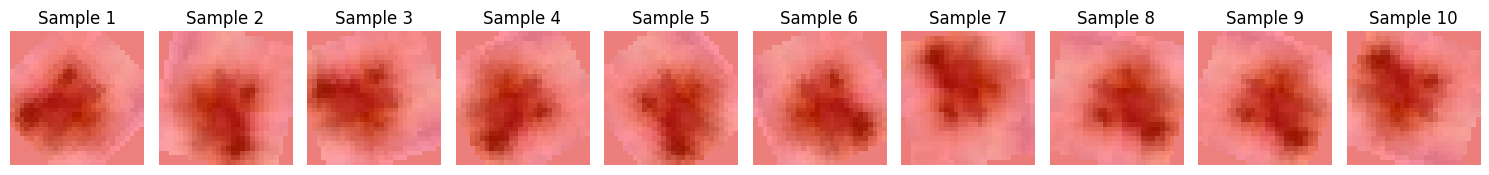

Verifying augmentations for index 200...


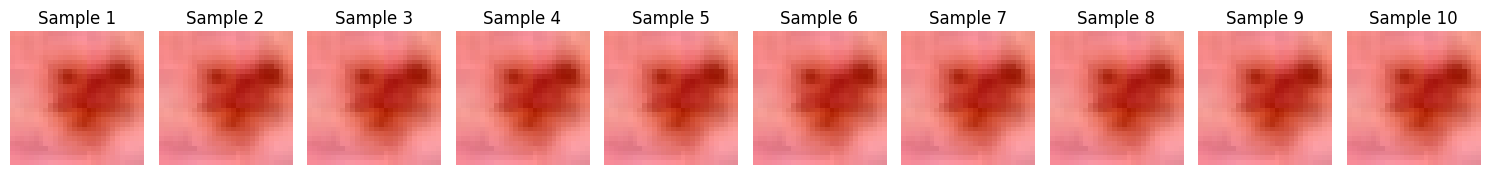

In [5]:
import matplotlib.pyplot as plt
import torch

def verify_dataloader_augmentations(dataloader, index=0, num_samples=5):
    """
    Directly inspects the dataset inside a DataLoader to verify 
    stochastic augmentations.
    """
    # Extract the dataset from the DataLoader
    dataset = dataloader.dataset
    
    plt.figure(figsize=(15, 5))
    print(f"Verifying augmentations for index {index}...")

    for i in range(num_samples):
        # Accessing the dataset directly triggers the transform pipeline
        image, label, _ = dataset[index]
        
        # Convert (C, H, W) -> (H, W, C)
        img_np = image.permute(1, 2, 0).numpy()
        
        # Min-Max scale for visualization (handles various pixel ranges)
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

        plt.subplot(1, num_samples, i + 1)
        # Squeeze handles grayscale (H, W, 1) -> (H, W)
        plt.imshow(img_np.squeeze(), cmap='gray' if img_np.shape[2] == 1 else None)
        plt.title(f"Sample {i+1}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

idx = 200
# 2. Pass the train_loader to the verification function
verify_dataloader_augmentations(train_dl, index=idx, num_samples=10)
verify_dataloader_augmentations(notrans_train_dl, index=idx, num_samples=10)

In [ ]:
model1.save_reconstructed_after_selection( notrans_train_dl, save_path = "../QTransformer_Results_and_Datasets/prov/selected_dataset", n_batches = 1 )

In [ ]:
from pathlib import Path
import torch

save_path = Path(f"../QTransformer_Results_and_Datasets/prov/selected_dataset")
save_path.mkdir(parents=True, exist_ok=True)
save_path_rec = Path(f"../QTransformer_Results_and_Datasets/prov/selected_dataset/rec")
save_path_ori = Path(f"../QTransformer_Results_and_Datasets/prov/selected_dataset/ori")
save_path_rec.mkdir(parents=True, exist_ok=True)
save_path_ori.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def save_reconstructed_after_selection(model1: torch.nn.Module , notrans_train_dl : torch.utils.data.DataLoader , save_path = "prov/selected_dataset",n_batches : int = 1 ) -> None:
    from pathlib import Path
    from PIL import Image
    import numpy as np

    save_path_rec = Path(save_path + "/reconstructed")
    save_path_ori = Path(save_path + "/ori")
    save_path = Path(save_path)
    save_path.mkdir(parents=True, exist_ok=True)
    save_path_rec.mkdir(parents=True, exist_ok=True)
    save_path_ori.mkdir(parents=True, exist_ok=True)

    count = 0

    for img, lbl, idx in notrans_train_dl:
        count += 1
        # Move batch to the same device as the model (use non_blocking if dataloader has pin_memory=True)
        img = img.to(device, non_blocking=True)
        _, indices_sel = model1.get_patches_by_attention(img)
        imgs_sel = model1.get_selected_pixel_patches(img, indices_sel)
        print(f"imgs_sel.shape: {imgs_sel.shape}, indices_sel.shape {indices_sel.shape}" )
        reconstructed_imgs = model1.reconstruct_image_from_patches(imgs_sel,indices_sel, shape)
        # reconstructed_imgs is expected as a torch.Tensor with shape (B, C, H, W) or (B, H, W, C)
        for b_i in range(reconstructed_imgs.shape[0]):
            recon = reconstructed_imgs[b_i].detach().cpu().numpy()
            # If channel-first (C,H,W) -> convert to H,W,C
            if recon.ndim == 3 and recon.shape[0] in (1, 3):
                recon = np.transpose(recon, (1, 2, 0))
            # If single-channel with last dim == 1 -> squeeze
            if recon.ndim == 3 and recon.shape[2] == 1:
                recon = recon[:, :, 0]
            # Normalize to 0..255 uint8
            minv, maxv = float(recon.min()), float(recon.max())
            if maxv <= 1.0 and minv >= 0.0:
                img_uint8 = (recon * 255.0).astype(np.uint8)
            else:
                rng = maxv - minv + 1e-8
                img_uint8 = ((recon - minv) / rng * 255.0).astype(np.uint8)
            # Create PIL image (grayscale or RGB)
            if img_uint8.ndim == 2:
                im = Image.fromarray(img_uint8, mode='L')
            else:
                if img_uint8.shape[2] > 3:
                    img_uint8 = img_uint8[:, :, :3]
                im = Image.fromarray(img_uint8)
            # Try to resolve a dataset index from the dataloader 'idx' (tensor or list), fallback to batch-local index
            try:
                sample_idx = int(idx[b_i].item())
            except Exception:
                try:
                    sample_idx = int(idx[b_i])
                except Exception:
                    sample_idx = b_i
            # Save reconstructed image
            fname = save_path_rec / f"recon_{sample_idx}_{b_i}.png"
            im.save(str(fname))
            # Also save the original input image in save_path_ori using the same index
            try:
                orig = img[b_i].detach().cpu().numpy()
            except Exception:
                # fallback if img is already numpy or other format
                orig = np.array(img[b_i])
            if orig.ndim == 3 and orig.shape[0] in (1, 3):
                orig = np.transpose(orig, (1, 2, 0))
            if orig.ndim == 3 and orig.shape[2] == 1:
                orig = orig[:, :, 0]
            minv_o, maxv_o = float(orig.min()), float(orig.max())
            if maxv_o <= 1.0 and minv_o >= 0.0:
                orig_uint8 = (orig * 255.0).astype(np.uint8)
            else:
                rng_o = maxv_o - minv_o + 1e-8
                orig_uint8 = ((orig - minv_o) / rng_o * 255.0).astype(np.uint8)
            if orig_uint8.ndim == 2:
                im_o = Image.fromarray(orig_uint8, mode='L')
            else:
                if orig_uint8.shape[2] > 3:
                    orig_uint8 = orig_uint8[:, :, :3]
                im_o = Image.fromarray(orig_uint8)
            fname_o = save_path_ori / f"origin_{sample_idx}_{b_i}.png"
            im_o.save(str(fname_o))
        # Optional: break after first batch when testing to avoid saving whole dataset
        if count >= n_batches:
            break

Using device: cuda:0
imgs_sel.shape: torch.Size([256, 25, 48]), indices_sel.shape torch.Size([256, 25])


In [ ]:
# Pennylane playground: angle embeddings, rotations, entangling gates, and simple visualizations
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt

# Helper: reduced density matrix for one qubit from a full statevector
def reduced_density_matrix(state, wire, n_wires):
    # state: shape (2**n_wires,)
    # reshape to (2,2,...,2)
    psi = state.reshape([2] * n_wires)
    # axes to keep for the subsystem
    keep = [wire]
    # axes to trace out
    trace_out = [i for i in range(n_wires) if i not in keep]
    # tensordot over traced-out axes between psi and psi.conj() -> reduced rho
    rho = np.tensordot(psi, np.conj(psi), axes=(trace_out, trace_out))
    # resulting shape (2,2) for single qubit
    return rho

# Helper: Bloch vector from 2x2 density matrix
def bloch_vector(rho):
    X = np.array([[0, 1], [1, 0]], dtype=complex)
    Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
    Z = np.array([[1, 0], [0, -1]], dtype=complex)
    return np.array([np.real(np.trace(rho @ X)),
                     np.real(np.trace(rho @ Y)),
                     np.real(np.trace(rho @ Z))])

# Build a simple QNode factory so you can change number of wires easily
def make_demo_qnode(n_wires=3, rotate=False, device_name='default.qubit'):
    dev = qml.device(device_name, wires=n_wires)

    @qml.qnode(dev)
    def circuit(inputs, rotate=rotate):
        # angle_embeddings: array-like of length n_wires (data embedding)
        # rx_angles: array-like of length n_wires (variational angles)
        qml.templates.AngleEmbedding(inputs, wires=range(n_wires))

        # simple variational layer: RX on each wire
        if rotate:
            qml.PauliRot(0.3, 'YZ', wires=[0, 1] )
            qml.PauliRot(-0.3, 'ZY', wires=[0, 1] )

        return qml.state()

    return circuit

# SelFormer Thingy

In [ ]:

# Hyperparams
p1 = {
    '1_learning_rate': 0.0025, '1_hidden_size': 48, '1_dropout': 0.3,
    '1_quantum' : False, '1_num_head': 4, '1_Attention_N' : 2, '1_num_transf': 2, '1_mlp_size': 5, '1_patch_size': 4, '1_weight_decay': 1e-7, '1_attention_selection': 'none', 
    '1_selection_amount': 20, '1_RD': 1, '1_connectivity' : 'king' ,'1_entangle_method' : 'CRX', '1_special_cls' : 'none', '1_paralel': 1, '1_patience': -1, 
    '1_scheduler_factor': 0.985, '1_q_stride': 1, '1_ancilla' : 0, '1_channels_out' : list(range(9)), '1_augmentation_prob' : 0, '1_val_train_pond' : 1,
    '1_flatten_extra_channels' : False, '1_quanv_kernel_size' : 3
}

p2 = {
    'learning_rate': 0.0025, 'hidden_size': 48, 'dropout': 0.3,
    'quantum' : False, 'num_head': 4, 'Attention_N' : 2, 'num_transf': 2, 'mlp_size': 5, 'patch_size': 4, 'weight_decay': 1e-7, 'attention_selection': 'filter',
    'selection_amount': 20, 'RD': 1, 'special_cls' : 'none', 'paralel': 2, 'patience': -1, 'scheduler_factor': 0.985, 'q_stride': 1, 'augmentation_prob' : 0,
    'val_train_pond' : 1, 'len_channels_scaler' : 2
}

exp_config = {
    'channels_last'         : False,         # True if last dimension of datasets tensors match channels dimension
    'repeat_selector'       : False,         # True to train autoencoder each time for more variability
    'send_telegram'         : True,
    'num_experiments'       : 1,
    'num_classes'           : 7,
    'trained_selector_once' : False,
    'pixels'                : 28,
    'experiment_name'       : 'Resolution224/16x16patches/kernel3x3 Selformer',
    'experiment_id'         : 'final_stand/3x3/dropout_channels/extra_patches/4x4patches/concatenate_original',
    'variant'               : 'selformer',
    'B'                     : 256,
    'special_batch_for_data': False,
    'rewind_channels'       : False,
    'N1'                    : 1,
    'N2'                    : 20,
    'q_config'              : {'patchwise','none'},
    'device'                : torch.device("cuda:0" if torch.cuda.is_available() else "cpu"),
    'second_at_a_time'      : False,
    'augmenting'            : False,
    'concatenate_original'  : True
}

# Helper functions: 
def make_dropout(drop):
    return {'embedding_attn': drop, 'after_attn': drop, 'feedforward': drop, 'embedding_pos': drop}

# Playground

Using downloaded and verified file: /home/carlosR/.medmnist/dermamnist.npz
Using downloaded and verified file: /home/carlosR/.medmnist/dermamnist.npz
Using downloaded and verified file: /home/carlosR/.medmnist/dermamnist.npz
Loaded MedMNIST dataset 'dermamnist' with image size 28x28 and 3 channels.
Using downloaded and verified file: /home/carlosR/.medmnist/dermamnist.npz
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12


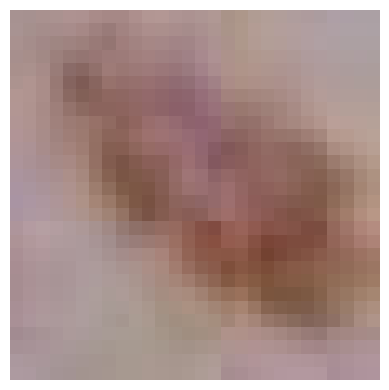

In [ ]:
import torch
import mi_quantum.data as data
from mi_quantum.quantum.quanvolution import QuantumConv2D
from mi_quantum.quantum.vit import VisionTransformer
import matplotlib.pyplot as plt
# Load data
notrans_train_dl, train_dl, val_dl, test_dl, shape = data.get_medmnist_dataloaders(
    pixel = exp_config['pixels'], data_flag='dermamnist', extra_tr_without_trans = True, batch_size=exp_config['B'], num_workers=4, pin_memory=True
)

def view_image_from_torch(tensor):
    image_np = tensor[0,...].permute(1, 2, 0).numpy()

    plt.figure(figsize=(15, 4))
    plt.imshow(image_np)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


model = VisionTransformer(
    img_size=28, num_channels=3, num_classes=exp_config['num_classes'],
    patch_size=p1['1_patch_size'], hidden_size= 3* p1['1_patch_size']**2, num_heads=p1['1_num_head'], Attention_N = p1['1_Attention_N'],
    num_transformer_blocks=p1['1_num_transf'], attention_selection= p1['1_attention_selection'], selection_amount = p1['1_selection_amount'], special_cls = p1['1_special_cls'], 
    mlp_hidden_size=p1['1_mlp_size'], quantum_mlp = False, dropout = make_dropout( p1['1_dropout']) , channels_last=exp_config['channels_last'], quantum_classification = False,
    paralel = p1['1_paralel'], RD = p1['1_RD'], q_stride = p1['1_q_stride'], connectivity = 'chain'
)

first_batch = next(iter(notrans_train_dl))[0]

shape = first_batch.shape
view_image_from_torch(first_batch)


# Lets explroe

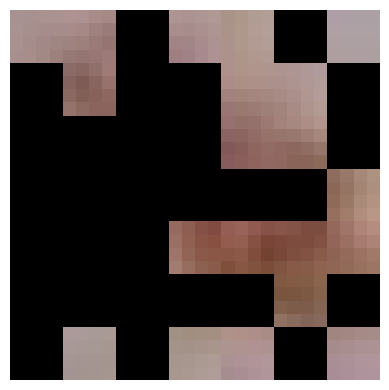

torch.Size([256, 20, 48])


In [ ]:
aux_patches, selected_indices = model.get_patches_by_attention(x=first_batch, paralel_branch=0)
reconstructed = model.reconstruct_image_from_patches(aux_patches, selected_indices, original_image_shape= shape, quantum_channels=0, originals = True).squeeze().detach()
view_image_from_torch(reconstructed)
print(aux_patches.shape)

In [ ]:
paddings = { 2 : { 'Up': 1, 'Down': 0, 'Left': 1, 'Right': 0 }, 3 : { 'Up': 1, 'Down': 1, 'Left': 1, 'Right': 1 } }

Quanvolution = QuantumConv2D(kernel_size = p1['1_quanv_kernel_size'], stride = 1, padding = paddings[p1['1_quanv_kernel_size']],
                             channels_out = p1['1_channels_out'],ancilla= p1['1_ancilla'],graph = p1['1_connectivity'],entangle_method = p1['1_entangle_method']
                            
)
aux_patches_processed = Quanvolution(aux_patches.reshape(-1, aux_patches.shape[-1]))

UnboundLocalError: local variable 'H' referenced before assignment

In [ ]:
import torch
import mi_quantum.data as data
from mi_quantum.quantum.vit import VisionTransformer

config = 'none'

# Now let's what's happening with the attentions!
train_dataset = torch.load("../QTransformer_Results_and_Datasets/selformer_results/quantum_datasets/quantum_train_dataset"+config+".pt", weights_only=True)
val_dataset = torch.load("../QTransformer_Results_and_Datasets/selformer_results/quantum_datasets/quantum_val_dataset"+config+".pt", weights_only=True)
test_dataset = torch.load("../QTransformer_Results_and_Datasets/selformer_results/quantum_datasets/quantum_test_dataset"+config+".pt", weights_only=True)

Latents = data.create_dataloaders(data_dir = None, batch_size= 256, channels_last= False, shuffle = False, tensors = [train_dataset, val_dataset, test_dataset], transforms={'train': None, 'val': None, 'test': None})
     
latent_train_dl, latent_val_dl, latent_test_dl = Latents[:-1]
first_batch = next(iter(latent_train_dl))[0]

model = VisionTransformer(
    img_size=28, num_channels=3, num_classes=exp_config['num_classes'],
    patch_size=p1['1_patch_size'], hidden_size= 3* p1['1_patch_size']**2, num_heads=p1['1_num_head'], Attention_N = p1['1_Attention_N'],
    num_transformer_blocks=p1['1_num_transf'], attention_selection= p1['1_attention_selection'], selection_amount = p1['1_selection_amount'], special_cls = p1['1_special_cls'], 
    mlp_hidden_size=p1['1_mlp_size'], quantum_mlp = False, dropout = make_dropout( p1['1_dropout']) , channels_last=exp_config['channels_last'], quantum_classification = False,
    paralel = p1['1_paralel'], RD = p1['1_RD'], q_stride = p1['1_q_stride'], connectivity = 'chain'
)

def rank_patches_by_attention(attn: torch.Tensor) -> torch.Tensor:
            """
            Ranks image patches by the total attention they receive.

            """
            # Average over heads: (B, T, T)
            attn_mean = attn.mean(dim=1)

            # Total attention received by each token: sum over the source positions (axis=-2)
            # attention_received[b, j] = sum over i of attn[b, i, j]
            attention_received = attn_mean.sum(dim=1)  # shape: (B, T)

            # Sort patches by total attention received, descending
            sorted_indices = attention_received.argsort(dim=1, descending=True)  # shape: (B, T)

            return sorted_indices

shape = first_batch.shape

Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12
Started a MutliheadSelfAttention layer with embed_dim: 48 num_heads: 4 head_dim: 12


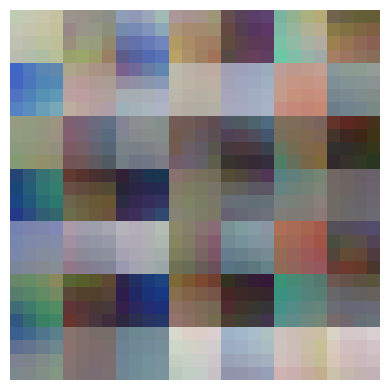

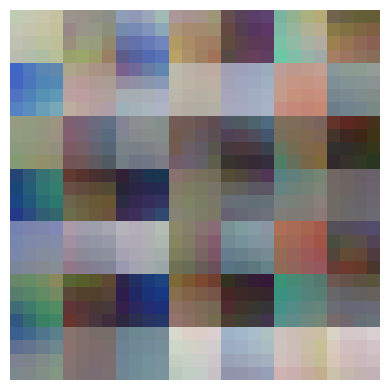

True

In [ ]:
aux = [48, 45, 47, 46] + list(range(45))

indices = torch.tensor(  aux ).unsqueeze(0).expand(shape[0],-1)

reconstructed = model.reconstruct_image_from_patches(first_batch, indices, (3,28,28), 1, True)
reconstructed.shape

sample_idx = 0

for idx in range(reconstructed.shape[1]):
    # Prepare for Matplotlib (H, W, C)
    image_np = reconstructed[sample_idx,idx,...].permute(1, 2, 0).numpy()

    plt.figure(figsize=(15, 4))
    plt.imshow(image_np)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

torch.allclose( reconstructed[sample_idx,0,...].permute(1, 2, 0), reconstructed[sample_idx,1,...].permute(1, 2, 0))

In [ ]:
import torch

sample = torch.rand(256, 3, 28, 28)

# 1. Unfold (Non-overlapping 4x4 patches)
# Shape: (256, 48, 49) -> (B, C*k*k, num_patches)
unfolding = torch.nn.Unfold(kernel_size=4, stride=4)
unfolded = unfolding(sample)

# 2. Fold (FIXED)
# - Set stride=4 to match the unfold operation
# - Set output_size=(28, 28) (Spatial dims only, not Channels)
folding = torch.nn.Fold(output_size=(28, 28), kernel_size=4, stride=4)

refolded = folding(unfolded)

print(f"Unfolded shape: {unfolded.shape}") # torch.Size([256, 48, 49])
print(f"Refolded shape: {refolded.shape}") # torch.Size([256, 3, 28, 28])

torch.allclose(sample, refolded)

Unfolded shape: torch.Size([256, 48, 49])
Refolded shape: torch.Size([256, 3, 28, 28])


True

Configuration:
Input Shape: [256, 98, 48]
Grid Layout: 7x7 patches
Target Single Image: 3x28x28
Target Concatenated: 3x28x56
------------------------------
Reconstructed Shape: torch.Size([256, 3, 28, 56])


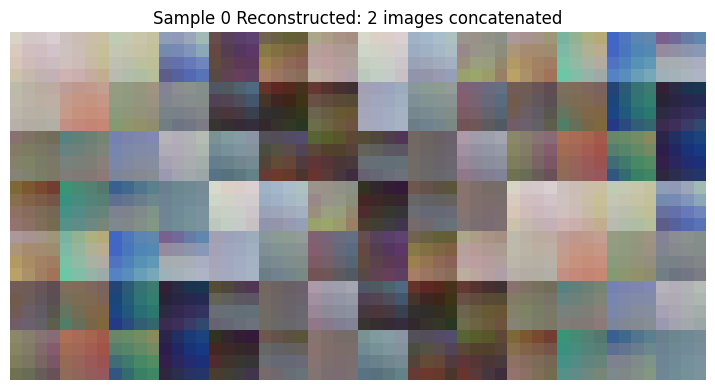

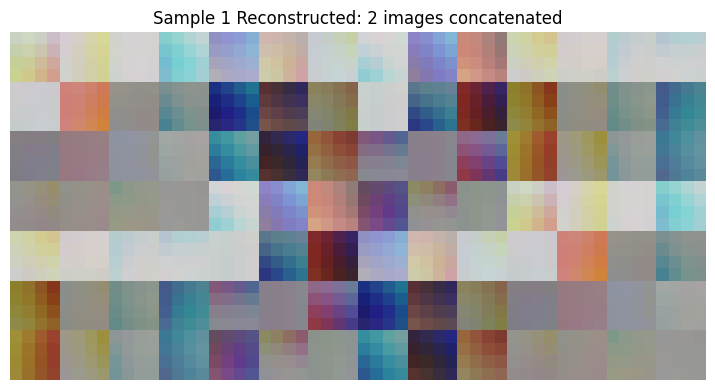

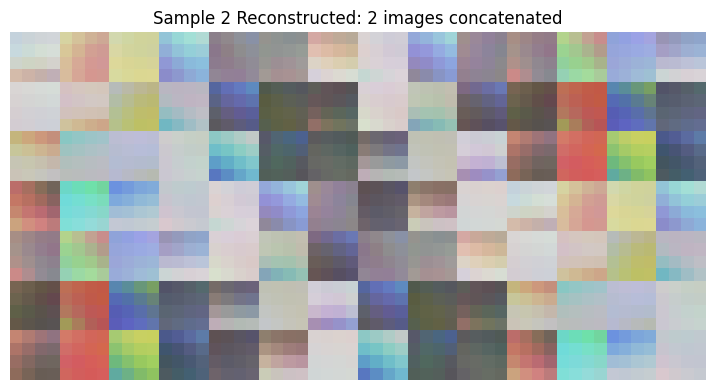

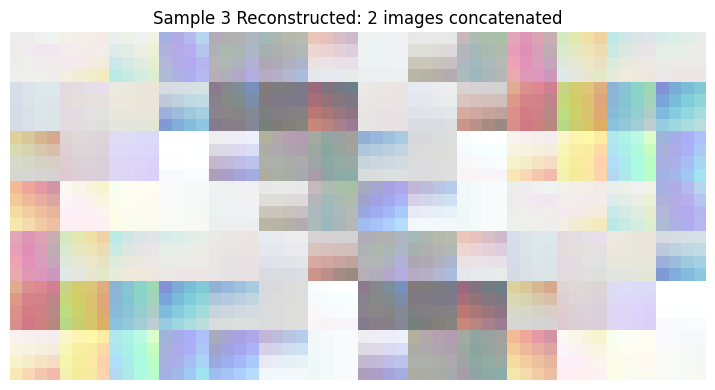

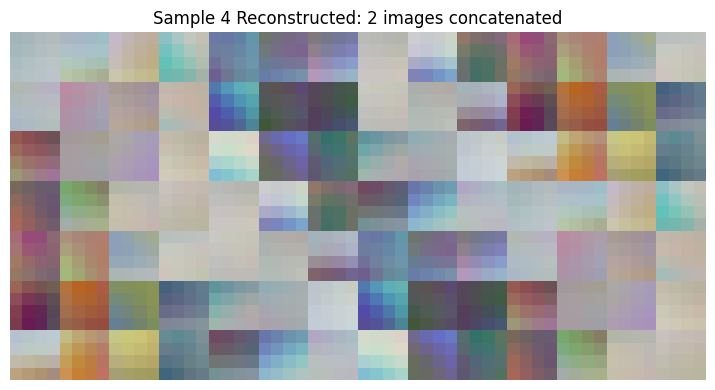

In [ ]:
#first_batch.shape = torch.Size([256, 490, 48]) # ( Batch, Number_of_Patches * Number_of_Images, Channels * Patch_size * Patch_size )
import torch
import matplotlib.pyplot as plt
import numpy as np

def visualize_tensor_reconstruction():
    # ---------------------------------------------------------
    # 1. Setup Configuration
    # ---------------------------------------------------------
    BATCH_SIZE, SEQ_LEN, EMBED_DIM  = first_batch.shape
    
    # Target dimensions
    N_IMGS = 2
    N_PATCHES_PER_IMG = 49
    IMG_H = 28
    IMG_W = 28
    PATCH_SIZE = 4
    CHANNELS = 3
    
    # Calculated grid size (e.g., 28 / 4 = 7)
    GRID_H = IMG_H // PATCH_SIZE
    GRID_W = IMG_W // PATCH_SIZE

    print(f"Configuration:")
    print(f"Input Shape: [{BATCH_SIZE}, {SEQ_LEN}, {EMBED_DIM}]")
    print(f"Grid Layout: {GRID_H}x{GRID_W} patches")
    print(f"Target Single Image: {CHANNELS}x{IMG_H}x{IMG_W}")
    print(f"Target Concatenated: {CHANNELS}x{IMG_H}x{IMG_W * N_IMGS}")
    print("-" * 30)

    # ---------------------------------------------------------
    # 2. Create Dummy Data
    # ---------------------------------------------------------
    # We use a gradient pattern so we can visually verify the reconstruction 
    # is correct (it shouldn't look like random noise if logic is right).
    # However, for this demo, random noise suffices to show shape.

    # ---------------------------------------------------------
    # 3. Reconstruction Logic (Pure PyTorch)
    # ---------------------------------------------------------
    def reconstruct(tensor):
            B = tensor.shape[0]
            
            # Step 1: Unflatten the Sequence Dimension
            # Crucial Fix: We split 490 into (49, 10) instead of (10, 49)
            # Shape: (B, N_PATCHES, N_IMGS, CHANNELS, PATCH_SIZE, PATCH_SIZE)
            x = tensor.view(B, N_PATCHES_PER_IMG, N_IMGS, CHANNELS, PATCH_SIZE, PATCH_SIZE)
            
            # Step 2: Reorder to group by Image (Swap Patches and Images)
            # Shape: (B, N_IMGS, N_PATCHES, CHANNELS, PATCH_SIZE, PATCH_SIZE)
            x = x.permute(0, 2, 1, 3, 4, 5)
            
            # Step 3: Unfold the linear patch list back into a 2D Grid (7x7)
            # Shape: (B, N_IMGS, GRID_H, GRID_W, CHANNELS, PATCH_SIZE, PATCH_SIZE)
            x = x.view(B, N_IMGS, GRID_H, GRID_W, CHANNELS, PATCH_SIZE, PATCH_SIZE)
            
            # Step 4: Permute to align spatial dimensions for standard image format
            # Shape: (B, N_IMGS, CHANNELS, GRID_H, PATCH_SIZE, GRID_W, PATCH_SIZE)
            x = x.permute(0, 1, 4, 2, 5, 3, 6)
            
            # Step 5: Merge the grid and patch dimensions
            # Shape: (B, N_IMGS, CHANNELS, IMG_H, IMG_W)
            x = x.reshape(B, N_IMGS, CHANNELS, IMG_H, IMG_W)
            
            # Step 6: Concatenate images horizontally
            x = x.permute(0, 2, 3, 1, 4)
            final_image = x.reshape(B, CHANNELS, IMG_H, N_IMGS * IMG_W)
            
            return final_image


    # ---------------------------------------------------------
    # 4. Execute and Visualize
    # ---------------------------------------------------------
    
    reconstructed_batch = reconstruct(first_batch)
    print(f"Reconstructed Shape: {reconstructed_batch.shape}") 
    # Expected: [256, 3, 28, 280]

    # Select the first sample to visualize
    for sample_idx in range(5):
        image_tensor = reconstructed_batch[sample_idx] # Shape: [3, 28, 280]

        # Prepare for Matplotlib (H, W, C)
        image_np = image_tensor.permute(1, 2, 0).numpy()

        plt.figure(figsize=(15, 4))
        plt.imshow(image_np)
        plt.title(f"Sample {sample_idx} Reconstructed: {N_IMGS} images concatenated")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    visualize_tensor_reconstruction()


torch.Size([100, 1])


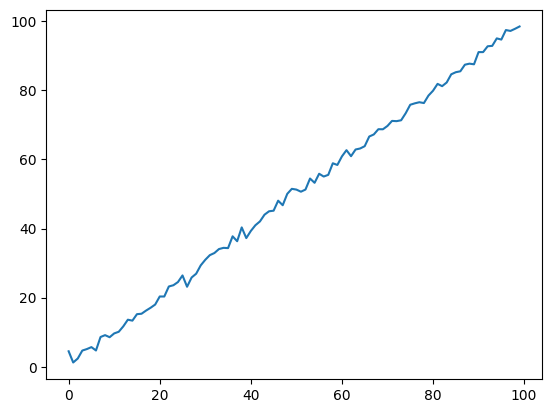

In [ ]:
import torch, numpy as np
import matplotlib.pyplot as plt

# Make mock data:

class MockTimeSeries():
    def __init__(self, shape = ( 100, 1 ), std = 1, slope = 1e-2):
        self.mean = torch.tensor([ i*slope for i in range(shape[0])]).unsqueeze(1).expand(shape)
        print(self.mean.shape)
        self.std = std
        self.series = self.mean + torch.normal(mean = self.mean, std = std)
    
    def plot(self):
        plt.plot(self.series)
        plt.show()

ts = MockTimeSeries( shape = ( 100, 1 ), std = 1, slope = 0.5)
ts.plot()

In [ ]:
import torch.nn.functional as F
import torch
import matplotlib.pyplot as plt

class TimeSeries():
    """
    A TimeSeries class inheriting from torch.Tensor.
    
    (Full docstring from previous version)
    """

    def __init__(self, data: torch.Tensor, time: torch.Tensor, channel_info: dict = None):
        # Ensure data is a 2D tensor with shape (num_channels + 1, series_length)
        if data.dim() != 2:
            raise ValueError("Data must be a 2D tensor with shape (num_channels, series_length)")
        if time.dim() != 1:
            raise ValueError("Time must be a 1D tensor with shape (,series_length)")

        self._data = data
        self._time = time
        self.channel_info = channel_info if channel_info is not None else {}

    @property
    def num_channels(self) -> int:
        return self._data.shape[0]

    @property
    def series_length(self) -> int:
        return self._data.shape[1]

    @property
    def time(self) -> torch.Tensor:
        return self._time

    @property
    def data(self) -> torch.Tensor:
        return self._data

    # --- Custom Plotting (Unchanged) ---
    
    def plot(self, title="Time Series Plot", xlabel="Time", ylabel="Value"):
        labels = [f'Channel {i+1}' for i in range(self.num_channels)] if not self.channel_info else [
            self.channel_info.get(i, f'Channel {i+1}') for i in range(self.num_channels)
        ]
        if plt is None:
            print("Cannot plot: matplotlib is not installed or imported.")
            return
            
        try:
            time_data = self.time.detach().cpu().numpy()
            data_channels = self.data.detach().cpu().numpy()
        except Exception as e:
            print(f"Error preparing data for plotting: {e}")
            return

        plt.figure(figsize=(10, 6))
        
        if self.num_channels > 0:
            for i, channel_data in enumerate(data_channels):
                plt.plot(time_data, channel_data, label=labels[i])
            plt.legend()
        elif self.num_channels == 0:
            print("Plotting time channel against index (no data channels found).")
            plt.plot(time_data, label='Time Channel')
            plt.legend()
            xlabel = "Index"
            ylabel = "Time Value"
        
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        plt.grid(True)
        plt.show()

    def unfold(self, kernel_size: int, stride: int = 1):
        """
        Applies a 1D sliding window (unfold) to the data and time tensors.

        Note: This uses torch.Tensor.unfold, which is the correct
        method for 1D sequential data. torch.nn.Unfold is for 2D images.

        Args:
            kernel_size (int): The size of the sliding window.
            stride (int): The step (slide) between adjacent windows.

        Returns:
            tuple[torch.Tensor, torch.Tensor]:
                - unfolded_data (torch.Tensor): Shape (num_channels, num_windows, kernel_size)
                - unfolded_time (torch.Tensor): Shape (num_windows, kernel_size)
        """

        # Unfold the data tensor: (C, L) -> (C, num_windows, kernel_size)
        # We unfold along dimension 1 (the time dimension)
        try:
            unfolded_data = self._data.unfold(dimension=1, size=kernel_size, step=stride)
        except RuntimeError as e:
            raise RuntimeError(f"Error unfolding data (shape {self._data.shape}): {e}") from e

        # Unfold the time tensor: (L,) -> (num_windows, kernel_size)
        try:
            unfolded_time = self._time.unfold(dimension=0, size=kernel_size, step=stride)
        except RuntimeError as e:
            raise RuntimeError(f"Error unfolding time (shape {self._time.shape}): {e}") from e

        # The number of windows should match
        if unfolded_data.shape[1] != unfolded_time.shape[0]:
            # This should not be reachable if self._data.shape[1] == self._time.shape[0]
            raise ValueError(
                "Unfolded data and time have mismatched window dimensions. "
                f"Data windows: {unfolded_data.shape[1]}, "
                f"Time windows: {unfolded_time.shape[0]}"
            )

        return unfolded_data, unfolded_time


    def compute_self_similarity(self, window_size=5, stride = 1, channel_wise=True, visualize=False, metric="cosine"):
        """
        Vectorized computation of self-similarity.
        
        Args:
            data (torch.Tensor): Input time series (Channels, Time).
            metric (str): "cosine" or "dot". Defaults to cosine.
        """
        # 1. Prepare Data (Vectorized Unfold)
        # Shape: (num_channels, num_windows, window_size)
        unfolded_data, _ = self.unfold(kernel_size=window_size, stride = stride) 
        num_channels, num_windows, k_size = unfolded_data.shape

        sim_matrix = None

        if channel_wise:

            windows = unfolded_data
            
            targets = unfolded_data[:, -1, :].unsqueeze(1)

            # Compute Similarity (Broadcasting happens on dim 1)
            if metric == "cosine":
                # F.cosine_similarity computes along dim=2 (the feature/window_size axis)
                sim_matrix = F.cosine_similarity(windows, targets, dim=2)
            elif metric == "dot":
                # Element-wise mult then sum
                sim_matrix = (windows * targets).sum(dim=2)

        else:
            # Compare ALL windows (flattened) against ALL last windows.

            # Shape: (num_channels, k_size)
            last_windows = unfolded_data[:, -1, :]

            # Shape: (num_channels * num_windows, k_size)
            all_windows = unfolded_data.reshape(-1, k_size)               

            # We need a matrix of shape: (num_channels, total_windows)
            # We expand dims to broadcast:
            # query: (1, total_windows, k_size)
            # ref:   (num_channels, 1, k_size)
            query = all_windows.unsqueeze(0)
            ref = last_windows.unsqueeze(1)
            
            if metric == "cosine":
                sim_matrix = F.cosine_similarity(query, ref, dim=2)
            elif metric == "dot":
                # Logic: Matrix Multiplication (Ref * Query_Transposed)
                # (num_channels, k) @ (k, total_windows) -> (num_channels, total_windows)
                sim_matrix = torch.matmul(last_windows, all_windows.T)
                # sim_matrix Shape: (num_channels, num_channels * num_windows)

        # --- VISUALIZATION ---
        if visualize:
            sim_matrix = sim_matrix.detach().cpu().numpy()
            plt.figure(figsize=(10, 6))
            
            if channel_wise:
                for c in range(num_channels):
                    plt.plot(sim_matrix[c], label=f'Channel {c+1}')
                plt.title("Vectorized Similarity (Channel-wise)")
            else:
                sim_tensor_3d = sim_matrix.reshape(num_channels, num_channels, num_windows)

                # 2. Create Grid
                fig, axes = plt.subplots(
                    nrows=num_channels, 
                    ncols=num_channels, 
                    figsize=(3 * num_channels, 2.5 * num_channels), # Dynamic sizing
                    sharex=True, 
                    sharey=True
                )
                
                # Handle case where num_channels=1 (axes is not 2D array)
                if num_channels == 1:
                    axes = [[axes]]

                # 3. Plot (i = Reference Channel, j = History Channel)
                for i in range(num_channels):
                    for j in range(num_channels):
                        ax = axes[i][j]
                        
                        # Plot the similarity profile
                        ax.plot(sim_tensor_3d[i, j], linewidth=1.5)
                        
                        # Formatting
                        ax.grid(True, linestyle='--', alpha=0.5)
                        
                        # Labels only on edges to reduce clutter
                        if i == 0:
                            ax.set_title(f"History: Ch {j+1}", fontsize=10, fontweight='bold')
                        if j == 0:
                            ax.set_ylabel(f"Ref: Ch {i+1}", fontsize=10, fontweight='bold')
                            
                fig.suptitle("Cross-Channel Similarity: Last Window (Rows) vs History (Cols)", y=1.02)
                plt.tight_layout()
                plt.show()
                
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.show()

        return sim_matrix, unfolded_data


    def forecast_by_similarity(self, similarity):
        pass


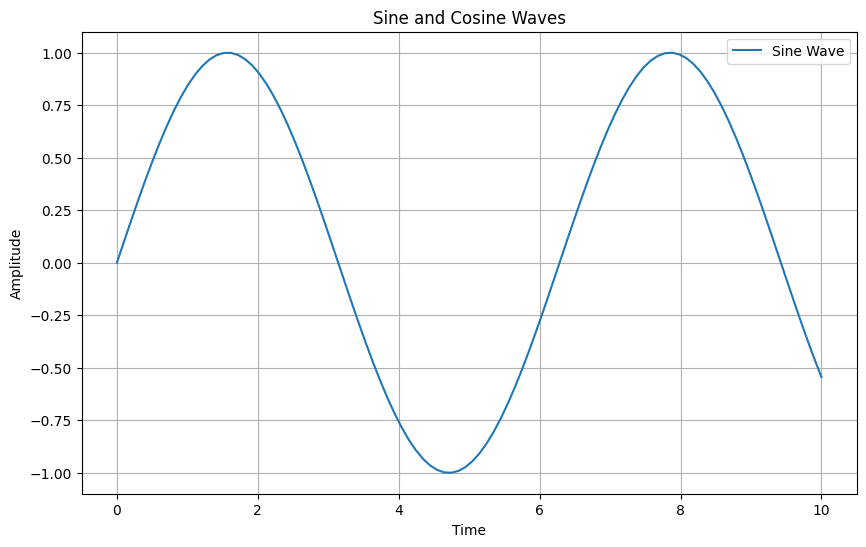

In [ ]:
time = torch.linspace(0, 10, steps=100)
data = torch.stack( [torch.sin(time)  ] )  # 2 channels , torch.cos(time)
channel_info = {0: 'Sine Wave'} #, 1: 'Cosine Wave'

ts = TimeSeries(data = data, time=time, channel_info=channel_info)
ts.plot(title="Sine and Cosine Waves", xlabel="Time", ylabel="Amplitude")

<Figure size 1000x600 with 0 Axes>

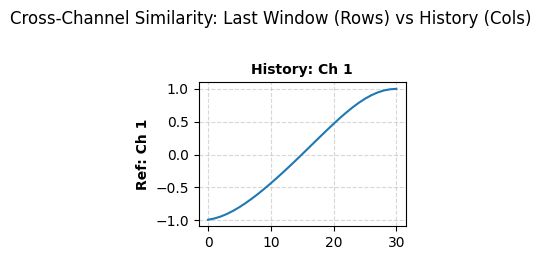

/tmp/ipykernel_2820381/3425240930.py:217: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


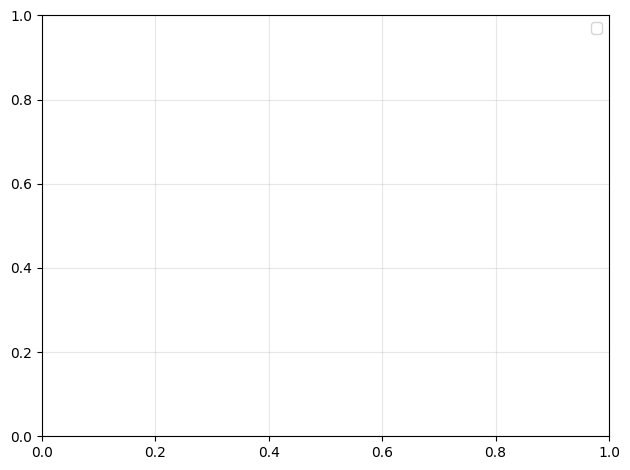

In [ ]:
a = ts.compute_self_similarity( window_size=70, stride = 1, visualize= True, channel_wise= False )

In [ ]:
import torch
N, M, L = 10, 5, 20
a = torch.randn(N, M, L)

In [ ]:
import torch

class FalseQubitSystem(torch.tensor):
    """
    A simple False Qubit class extending torch.tensor to represent a "qubit state" from its pseudo-coordinates on the Bloch sphere:
    Attributes:
        state (torch.tensor): A tensor of shape (2,) representing the (height, depth) coordinates on the Bloch sphere.
        height (float): The latitude (-1 to 1) -> defaults to -1 (|0> state).
        depth (float): The longitude (-1 to 1) -> defaults to -1 (Greenwich).
    """
    def __init__(self, states=torch.tensor([-1.0, -1.0])): # Default state |0> represented as (-1,0)
        assert states.shape[-1] == 2, "State must be a tensor of shape (..., 2) representing (height, depth) coordinates."
        super().__init__(states)

    def get_coordinates(self):
        """
        Returns the (height, depth) coordinates of the qubit state of given qubit.
        Returns:
            tuple: A tuple containing (height, depth).
        """
        height, depth = self[...,0].item(), self[...,1].item()
        return height, depth
    
    def measure(self):
        """
        Simulates a measurement of the qubit state.
        Returns:
            int: 0 or 1 based on the qubit state probabilities.
        """
        coordinates = self.get_coordinates()
        normalized = torch.nn.functional.normalize(coordinates, p = 2, dim = -1)

        prob_0 = (1 + normalized[..., 0]) / 2  # Probability of measuring |0>
        sampled = torch.rand_like(prob_0)
        return sampled >= prob_0
    
def Rotation(system, qubit, axis, angle):
    """
    Applies a rotation to the given qubit around the specified axis by the given angle.
    Args:
        system
        qubit (int): The qubit to be rotated.
        axis (str): The axis of rotation ('X', 'Y', or 'Z').
        angle (float): The angle of rotation in radians.
    Returns:
        FalseQubit: The rotated qubit.
    """
    vheight, vdepth = system.get_coordinates()
    height, depth = vheight[...,qubit], vdepth[...,qubit]
    
    if axis == 'X':
        new_height =   height * torch.sin(angle)
        new_depth   =   depth   * torch.cos(angle)
    elif axis == 'Y':
        new_height =   height * torch.cos(angle)
        new_depth   =   depth
    elif axis == 'Z':
        new_height =   height
        new_depth   =   depth   * torch.cos(angle) 
    else:
        raise ValueError("Axis must be 'X', 'Y', or 'Z'.")
    
    vheight[...,qubit], vdepth[...,qubit] = new_height, new_depth
    
    return FalseQubitSystem(torch.tensor([new_height, new_depth]))

    